# Данный файл содержит кодовую часть финального проекта по Научной студии (Поиск экспортных рынков).

План проекта:

- Подсчет метрик (HHI, RCA, ECI)

- Гравитационная модель

- Временные ряды

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, MSTL, seasonal_decompose
import comtradeapicall
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import time
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import io
import warnings

np.random.seed(42)
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# Списки перевода кодов стран

In [2]:
country_to_iso3 = {
    "Cote d'Ivoire": "CIV",
    "Egypt": "EGY",
    "Ethiopia": "ETH",
    "Ghana": "GHA",
    "Kenya": "KEN",
    "Morocco": "MAR",
    "Madagascar": "MDG",
    "Mozambique": "MOZ",
    "Mauritania": "MRT",
    "Mauritius": "MUS",
    "Namibia": "NAM",
    "Niger": "NER",
    "Togo": "TGO",
    "Tunisia": "TUN",
    "Tanzania": "TZA",
    "South Africa": "ZAF",
    "Zambia": "ZMB",
    "Zimbabwe": "ZWE",
    "United Arab Emirates": "ARE",
    "China": "CHN",
    "Hong Kong": "HKG",
    "Indonesia": "IDN",
    "India": "IND",
    "Iran": "IRN",
    "Israel": "ISR",
    "Jordan": "JOR",
    "Japan": "JPN",
    "Cambodia": "KHM",
    "South Korea": "KOR",
    "Laos": "LAO",
    "Lebanon": "LBN",
    "Sri Lanka": "LKA",
    "Malaysia": "MYS",
    "Philippines": "PHL",
    "Saudi Arabia": "SAU",
    "Singapore": "SGP",
    "Thailand": "THA",
    "Turkey": "TUR",
    "Chinese Taipei": "TWN",  
    "Uzbekistan": "UZB",
    "Vietnam": "VNM",
    "Austria": "AUT",
    "Belgium": "BEL",
    "Bulgaria": "BGR",
    "Belarus": "BLR",
    "Switzerland": "CHE",
    "Czechia": "CZE",
    "Germany": "DEU",
    "Denmark": "DNK",
    "Spain": "ESP",
    "Estonia": "EST",
    "Finland": "FIN",
    "France": "FRA",
    "United Kingdom": "GBR",
    "Greece": "GRC",
    "Croatia": "HRV",
    "Hungary": "HUN",
    "Ireland": "IRL",
    "Italy": "ITA",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Latvia": "LVA",
    "Malta": "MLT",
    "Netherlands": "NLD",
    "Norway": "NOR",
    "Poland": "POL",
    "Portugal": "PRT",
    "Romania": "ROU",
    "Russia": "RUS",
    "Serbia": "SRB",
    "Slovakia": "SVK",
    "Slovenia": "SVN",
    "Sweden": "SWE",
    "Ukraine": "UKR",
    "Canada": "CAN",
    "Costa Rica": "CRI",
    "Dominican Republic": "DOM",
    "Guatemala": "GTM",
    "Honduras": "HND",
    "Mexico": "MEX",
    "Nicaragua": "NIC",
    "Panama": "PAN",
    "El Salvador": "SLV",
    "Trinidad and Tobago": "TTO",
    "United States": "USA",
    "Australia": "AUS",
    "New Zealand": "NZL",
    "Argentina": "ARG",
    "Brazil": "BRA",
    "Chile": "CHL",
    "Colombia": "COL",
    "Ecuador": "ECU",
    "Peru": "PER",
    "Angola": "AGO",
    "Burundi": "BDI",
    "Republic of the Congo": "COG",
    "Malawi": "MWI",
    "Nigeria": "NGA",
    "Senegal": "SEN",
    "Eswatini": "SWZ",
    "Uganda": "UGA",
    "Cyprus": "CYP",
    "Kyrgyzstan": "KGZ",
    "Pakistan": "PAK",
    "Iceland": "ISL",
    "Bolivia": "BOL",
    "Guyana": "GUY",
    "Botswana": "BWA",
    "Azerbaijan": "AZE",
    "Georgia": "GEO",
    "Qatar": "QAT",
    "Barbados": "BRB",
    "Paraguay": "PRY",
    "Uruguay": "URY",
    "Gambia": "GMB",
    "Brunei": "BRN",
    "Oman": "OMN",
    "Andorra": "AND",
    "Bermuda": "BMU",
    "Cuba": "CUB",
    "Benin": "BEN",
    "Burkina Faso": "BFA",
    "Gabon": "GAB",
    "Kazakhstan": "KAZ",
    "Burma": "MMR", 
    "Fiji": "FJI",
    "Democratic Republic of the Congo": "COD",
    "Eritrea": "ERI",
    "Papua New Guinea": "PNG",
    "New Caledonia": "NCL"
}

In [3]:
iso3_to_ru = {
    'ABW': 'Аруба', 'AFG': 'Афганистан', 'AGO': 'Ангола', 'AIA': 'Ангилья', 
    'ALB': 'Албания', 'AND': 'Андорра', 'ANT': 'Нидерландские Антильские острова', 
    'ARE': 'ОАЭ', 'ARG': 'Аргентина', 'ARM': 'Армения', 'ASM': 'Американское Самоа', 
    'ATG': 'Антигуа и Барбуда', 'AUS': 'Австралия', 'AUT': 'Австрия', 'AZE': 'Азербайджан', 
    'BDI': 'Бурунди', 'BEL': 'Бельгия', 'BEN': 'Бенин', 'BES': 'Бонэйр, Синт-Эстатиус и Саба', 
    'BFA': 'Буркина-Фасо', 'BGD': 'Бангладеш', 'BGR': 'Болгария', 'BHR': 'Бахрейн', 
    'BHS': 'Багамские Острова', 'BIH': 'Босния и Герцеговина', 'BLR': 'Беларусь', 
    'BLZ': 'Белиз', 'BMU': 'Бермудские острова', 'BOL': 'Боливия', 'BRA': 'Бразилия', 
    'BRB': 'Барбадос', 'BRN': 'Бруней', 'BTN': 'Бутан', 'BWA': 'Ботсвана', 
    'CAF': 'ЦАР', 'CAN': 'Канада', 'CCK': 'Кокосовые острова', 'CHE': 'Швейцария', 
    'CHL': 'Чили', 'CHN': 'Китай', 'CIV': "Кот-д'Ивуар", 'CMR': 'Камерун', 
    'COD': 'ДР Конго', 'COG': 'Республика Конго', 'COK': 'Острова Кука', 
    'COL': 'Колумбия', 'COM': 'Коморские Острова', 'CPV': 'Кабо-Верде', 
    'CRI': 'Коста-Рика', 'CUB': 'Куба', 'CUW': 'Кюрасао', 'CXR': 'Остров Рождества', 
    'CYM': 'Каймановы острова', 'CYP': 'Кипр', 'CZE': 'Чехия', 'DEU': 'Германия', 
    'DJI': 'Джибути', 'DMA': 'Доминика', 'DNK': 'Дания', 'DOM': 'Доминиканская Республика', 
    'DZA': 'Алжир', 'ECU': 'Эквадор', 'EGY': 'Египет', 'ERI': 'Эритрея', 
    'ESP': 'Испания', 'EST': 'Эстония', 'ETH': 'Эфиопия', 'FIN': 'Финляндия', 
    'FJI': 'Фиджи', 'FLK': 'Фолклендские острова', 'FRA': 'Франция', 
    'FSM': 'Микронезия', 'GAB': 'Габон', 'GBR': 'Великобритания', 'GEO': 'Грузия', 
    'GHA': 'Гана', 'GIB': 'Гибралтар', 'GIN': 'Гвинея', 'GMB': 'Гамбия', 
    'GNB': 'Гвинея-Бисау', 'GNQ': 'Экваториальная Гвинея', 'GRC': 'Греция', 
    'GRD': 'Гренада', 'GRL': 'Гренландия', 'GTM': 'Гватемала', 'GUM': 'Гуам', 
    'GUY': 'Гайана', 'HKG': 'Гонконг', 'HND': 'Гондурас', 'HRV': 'Хорватия', 
    'HTI': 'Гаити', 'HUN': 'Венгрия', 'IDN': 'Индонезия', 'IND': 'Индия', 
    'IOT': 'Британская территория в Индийском океане', 'IRL': 'Ирландия', 
    'IRN': 'Иран', 'IRQ': 'Ирак', 'ISL': 'Исландия', 'ISR': 'Израиль', 
    'ITA': 'Италия', 'JAM': 'Ямайка', 'JOR': 'Иордания', 'JPN': 'Япония', 
    'KAZ': 'Казахстан', 'KEN': 'Кения', 'KGZ': 'Кыргызстан', 'KHM': 'Камбоджа', 
    'KIR': 'Кирибати', 'KNA': 'Сент-Китс и Невис', 'KOR': 'Южная Корея', 
    'KWT': 'Кувейт', 'LAO': 'Лаос', 'LBN': 'Ливан', 'LBR': 'Либерия', 
    'LBY': 'Ливия', 'LCA': 'Сент-Люсия', 'LKA': 'Шри-Ланка', 'LSO': 'Лесото', 
    'LTU': 'Литва', 'LUX': 'Люксембург', 'LVA': 'Латвия', 'MAC': 'Макао', 
    'MAR': 'Марокко', 'MDA': 'Молдова', 'MDG': 'Мадагаскар', 'MDV': 'Мальдивы', 
    'MEX': 'Мексика', 'MHL': 'Маршалловы Острова', 'MKD': 'Северная Македония', 
    'MLI': 'Мали', 'MLT': 'Мальта', 'MMR': 'Мьянма', 'MNE': 'Черногория', 
    'MNG': 'Монголия', 'MNP': 'Северные Марианские острова', 'MOZ': 'Мозамбик', 
    'MRT': 'Мавритания', 'MSR': ' Монтсеррат', 'MUS': 'Маврикий', 'MWI': 'Малави', 
    'MYS': 'Малайзия', 'MYT': 'Майотта', 'NAM': 'Намибия', 'NCL': 'Новая Каледония', 
    'NER': 'Нигер', 'NFK': 'Остров Норфолк', 'NGA': 'Нигерия', 'NIC': 'Никарагуа', 
    'NIU': 'Ниуэ', 'NLD': 'Нидерланды', 'NOR': 'Норвегия', 'NPL': 'Непал', 
    'NRU': 'Науру', 'NZL': 'Новая Зеландия', 'OMN': 'Оман', 'PAK': 'Пакистан', 
    'PAN': 'Панама', 'PCN': 'Питкэрн', 'PER': 'Перу', 'PHL': 'Филиппины', 
    'PLW': 'Палау', 'PNG': 'Папуа — Новая Гвинея', 'POL': 'Польша', 
    'PRK': 'Северная Корея', 'PRT': 'Португалия', 'PRY': 'Парагвай', 
    'PSE': 'Палестина', 'PYF': 'Французская Полинезия', 'QAT': 'Катар', 
    'ROU': 'Румыния', 'RUS': 'Россия', 'RWA': 'Руанда', 'SAU': 'Саудовская Аравия', 
    'SCG': 'Сербия и Черногория (бывш.)', 'SDN': 'Судан', 'SEN': 'Сенегал', 
    'SGP': 'Сингапур', 'SHN': 'Остров Святой Елены', 'SLB': 'Соломоновы Острова', 
    'SLE': ' Сьерра-Леоне', 'SLV': 'Сальвадор', 'SMR': 'Сан-Марино', 
    'SOM': 'Сомали', 'SPM': 'Сен-Пьер и Микелон', 'SRB': 'Сербия', 
    'SSD': 'Южный Судан', 'STP': 'Сан-Томе и Принсипи', 'SUR': 'Суринам', 
    'SVK': 'Словакия', 'SVN': 'Словения', 'SWE': 'Швеция', 'SWZ': 'Эсватини', 
    'SXM': 'Синт-Мартен', 'SYC': 'Сейшельские Острова', 'SYR': 'Сирия', 
    'TCA': 'Теркс и Кайкос', 'TCD': 'Чад', 'TGO': 'Того', 'THA': 'Таиланд', 
    'TJK': 'Таджикистан', 'TKL': 'Токелау', 'TKM': 'Туркменистан', 
    'TLS': 'Восточный Тимор', 'TON': 'Тонга', 'TTO': 'Тринидад и Тобаго', 
    'TUN': 'Тунис', 'TUR': 'Турция', 'TUV': 'Тувалу', 'TWN': 'Тайвань', 
    'TZA': 'Танзания', 'UGA': 'Уганда', 'UKR': 'Украина', 'URY': 'Уругвай', 
    'USA': 'США', 'UZB': 'Узбекистан', 'VCT': 'Сент-Винсент и Гренадины', 
    'VEN': 'Венесуэла', 'VGB': 'Виргинские острова (Брит.)', 'VNM': 'Вьетнам', 
    'VUT': 'Вануату', 'WLF': 'Уоллис и Футуна', 'WSM': 'Самоа', 'YEM': 'Йемен', 
    'ZAF': 'ЮАР', 'ZMB': 'Замбия', 'ZWE': 'Зимбабве'
}

# Парсеры данных

In [4]:
def load_wb_indicator(countries, indicator):
    url = (
        "https://api.worldbank.org/v2/country/"
        + ";".join(countries)
        + f"/indicator/{indicator}"
        + "?format=json&per_page=2000"
    )
    raw = requests.get(url).json()

    records = []
    if raw and len(raw) > 1:
        for item in raw[1]:
            records.append({
                "country": item["country"]["value"],
                "country_code": item["countryiso3code"],
                "year": int(item["date"]),
                "value": item["value"]
            })
    return pd.DataFrame(records)

In [5]:
def load_wb_indicator_batch(countries, indicator):
    batch_size = 31
    df = pd.DataFrame()
    for i in range(0, len(countries), batch_size):
        countries_batch = countries[i:i + batch_size]
        df_batch = load_wb_indicator(countries=countries_batch, indicator=indicator)
        df = pd.concat([df, df_batch], axis=0)
    return df

In [6]:
def load_oec_data(hs_level, years):
    url = (
        "https://api-v2.oec.world/tesseract/data.jsonrecords?"
        "cube=trade_i_baci_a_17"
        f"&drilldowns={hs_level},Exporter+Country"
        f"&include=Year:{years}"
        "&locale=en"
        "&measures=Trade+Value"
    )

    response = requests.get(url)
    json_data = response.json()
    return pd.DataFrame(json_data["data"])

In [7]:
def load_oec_datas(hs_level: str, years: list):

  df = pd.DataFrame()

  for year in years:
    df_year = load_oec_data(hs_level=hs_level, years=year)
    df_year['Year'] = year
    df = pd.concat([df, df_year], axis=0)

  return df

In [8]:
df = load_oec_datas(hs_level='HS6', years=['2018', '2019', '2020', '2021', '2022', '2023', '2024'])

In [9]:
def load_oec_data_import(hs_level, hs_code, years):
    url = (
        "https://api-v2.oec.world/tesseract/data.jsonrecords?"
        "cube=trade_i_baci_a_17"
        f"&drilldowns={hs_level},Exporter+Country,Importer+Country"
        f"&include=Year:{years}"
        f"&HS6={hs_code}"
        "&locale=en"
        "&measures=Trade+Value"
    )

    response = requests.get(url)
    json_data = response.json()
    return pd.DataFrame(json_data["data"])

In [10]:
def load_oec_datas_import(hs_level: str, years: list, hs_code: int):

  df = pd.DataFrame()

  for year in years:
    df_year = load_oec_data_import(hs_level=hs_level, years=year, hs_code=hs_code)
    df_year['Year'] = year
    df = pd.concat([df, df_year], axis=0)

  return df

df_potash_import = load_oec_datas_import(hs_level='HS6', years=['2018', '2019', '2020', '2021', '2022', '2023', '2024'], hs_code=6310490)

In [11]:
def load_us_census(hs_code):
    BASE = "https://api.census.gov/data/timeseries/intltrade/exports/hs"

    j = requests.get(
        BASE,
        params={"get": "YEAR,MONTH,E_COMMODITY,CTY_CODE,ALL_VAL_MO", "CTY_CODE": "-", "E_COMMODITY": hs_code},
        timeout=60,
    ).json()

    df = pd.DataFrame(j[1:], columns=j[0])
    idx = pd.to_datetime(df["YEAR"] + "-" + df["MONTH"].str.zfill(2) + "-01")

    return pd.Series(pd.to_numeric(df["ALL_VAL_MO"]).values, index=idx, name=hs_code).sort_index().asfreq("MS").interpolate("time") / 1e6

In [12]:
url_cepii = "https://www.cepii.fr/DATA_DOWNLOAD/gravity/data/Gravity_csv_V202211.zip"

response = requests.get(url_cepii)

with open("gravity_temp.zip", "wb") as f:
    f.write(response.content)

with zipfile.ZipFile("gravity_temp.zip", "r") as zip_ref:
    zip_ref.extract("Gravity_V202211.csv")

df_cepii = pd.read_csv(r"Gravity_V202211.csv", sep=',', encoding='utf-8', on_bad_lines='skip').dropna(subset='tradeflow_baci')

In [13]:
# Пример кода с un comtrade откуда взят парсер
# https://github.com/uncomtrade/comtradeapicall/blob/main/tests/example%20calling%20functions%20-%20notebook.ipynb

In [14]:
def load_un_comtrade(periods: list, hs_code: str):
    subscription_key = '<YOUR KEY>'
    directory = '<OUTPUT DIR>'  
    proxy_url = '<PROXY URL>'

    df_list = []

    columns_to_save = [
        "period",
        "reporterDesc",  
        "cmdCode",  
        "cmdDesc",  
        "primaryValue",  
    ]

    for i in range(0, len(periods), 12):

        period = ",".join(map(str, periods[i:i+12]))

        df_period = comtradeapicall.previewFinalData(
            typeCode="C",  
            freqCode="M",  
            clCode="HS",  
            period=period,  
            reporterCode="643", 
            cmdCode=f"{hs_code}",  
            flowCode="X",  
            partnerCode="0",  
            partner2Code=None,
            customsCode=None,
            motCode=None,
            maxRecords=2500,  
            includeDesc=True,
        )

        if df_period is not None and not df_period.empty:
            df_period = df_period.loc[:, columns_to_save]
            df_list.append(df_period)

    return pd.concat(df_list, axis=0)

In [15]:
dates_list = []

for year in range(2013, 2025):
    for month in range(1, 13):
        if len(str(month)) == 1:
            dates_list.append(str(year) + '0' + str(month))
        else:
            dates_list.append(str(year) + str(month))

In [16]:
df_potash_comtrade = load_un_comtrade(periods=dates_list, hs_code='3104')
df_gas_comtrade = load_un_comtrade(periods=dates_list, hs_code='2711')
df_tomato_comtrade = load_un_comtrade(periods=dates_list, hs_code='0702')

# 1. Торгово-экономические индексы

In [17]:
mask_potash = df['HS6 ID'] == 6310490
df_potash = df[mask_potash]

mask_ru = df['Exporter Country'] == 'Russia'
df_ru = df[mask_ru]

In [18]:
df_ru = df_ru[['Exporter Country', 'HS6 ID', 'HS6', 'Trade Value', 'Year']]

Вычислим индекс Херфиндаля-Хиршмана по годам (2018-2024). 

$\text{HHI} = \sum\limits_{i=1}^{N} s_{i}^{2}$, где $s_i$ - доля i-й страны на рынке, $N$ - общее количество стран.

In [19]:
hhi_by_year = df_ru.groupby('Year').apply(
    lambda x: ((x['Trade Value'] / x['Trade Value'].sum()) ** 2).sum() * 10000
)

print("Средний индекс HHI по годам:")
display(hhi_by_year.mean().round(2))

Средний индекс HHI по годам:


np.float64(1101.51)

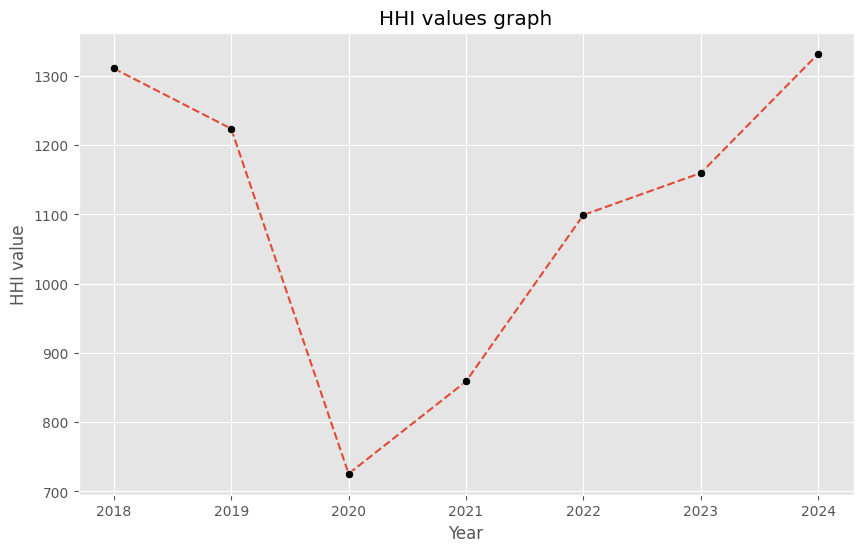

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=hhi_by_year.index, y=hhi_by_year, color='C0', ls='--')
sns.scatterplot(x=hhi_by_year.index, y=hhi_by_year, color='black', zorder=2)
plt.ylabel('HHI value')
plt.title('HHI values graph')
plt.show()

Согласно результатам расчетов за 2018–2024 годы, индекс Херфиндаля-Хиршмана для мирового рынка калийных удобрений варьируется в диапазоне от 725,53 до 1332,16 пункта. Данные значения устойчиво находятся ниже пороговой отметки в 1500 пунктов, что свидетельствует о низком уровне концентрации и высокой (развитой) степени конкуренции на мировом рынке.

Теперь вычислим индекс сравнительного преимущества RCA:

$\text{RCA} = \frac{X_{c, p} / X_{c, total}}{X_{world, p} / X_{world, total}}$, где:
1.  $X_{c, p}$ — сколько страна $c$ экспортирует товара $p$. 
2. $X_{c, total}$ — сколько всего страна $c$ экспортирует (т.е. всех товаров).
3. $X_{world, p}$ — сколько весь мир экспортирует товар $p$.
4. $X_{world, total}$ — объем всей мировой торговли всеми товарами.

In [21]:
def compute_rca(hs6_id):

  mask = df_ru['HS6 ID'] == hs6_id
  X_c = df_ru[mask].set_index('Year')['Trade Value']

  X_c_sum = df_ru.groupby('Year')['Trade Value'].sum()

  X_word = df[df['HS6 ID'] == hs6_id].groupby('Year')['Trade Value'].sum()

  X_word_sum = df.groupby('Year')['Trade Value'].sum()

  RCA = (X_c / X_c_sum) / (X_word / X_word_sum)

  return RCA

In [22]:
rca_by_year = compute_rca(hs6_id = 6310490)

print('Среднее сравнительное преимущество России в экспорте Калийных удобрений 2018-2024 года:')
display(rca_by_year.mean().round(2))

Среднее сравнительное преимущество России в экспорте Калийных удобрений 2018-2024 года:


np.float64(3.06)

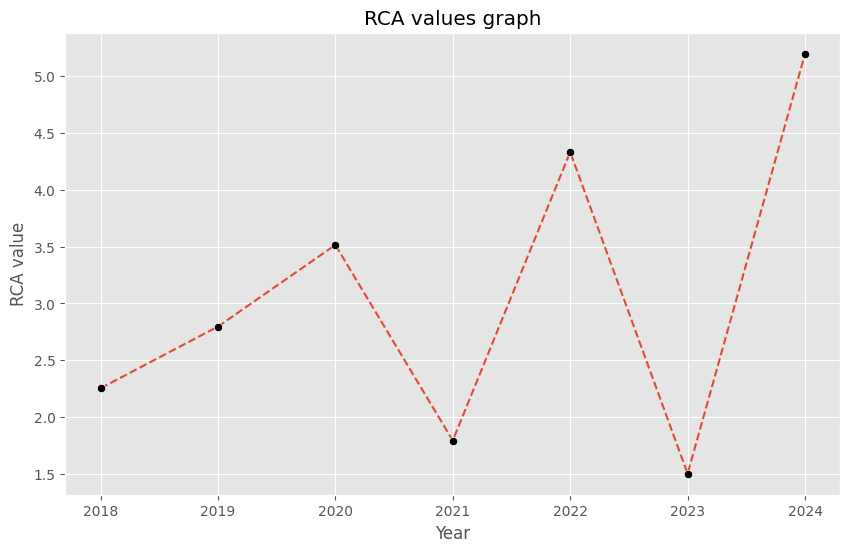

In [23]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=rca_by_year.index, y=rca_by_year, color='C0', ls='--')
sns.scatterplot(x=rca_by_year.index, y=rca_by_year, color='black', zorder=2)
plt.ylabel('RCA value')
plt.title('RCA values graph')
plt.show()

Во все года с 2018 по 2024 индекс сравнительного преимущества в экспорте калийных удобрений превышал 1, а в среднем составлял 3.06, что математически подтверждает глубокую специализацию России на производстве и экспорте калийных удобрений. Повышение индекса сравнительного преимущества от $\text{RCA} = 1.5$ до $\text{RCA} = 5.2$ в 2024 году говорит об успешной адаптации к санкциям, введенным в 2022-2023 годах санкицям, а так же переориентации рынка на дружественные страны.

Вычислим индекс экономической сложности страны:

$\text{ECI} = \frac{k_{c} - \langle k_{c} \rangle}{\sigma(k_{c})}$, где $k_{c, n} = \frac{1}{k_{c, 0}} \sum\limits_{p}M_{cp}, k_{p, n-1}$, $k_{p, n} = \frac{1}{k_{p, 0}} \sum\limits_{c}M_{cp}, k_{c, n-1}$, $k_{c,0} = \sum\limits_{p}M_{cp}$, $k_{p, 0} = \sum\limits_{c}M_{cp}$, 

$M_{cp} = \begin{cases} 1, \ \text{RCA} \ge 1 \\ 0, \ \text{RCA} < 1 \end{cases}$

In [24]:
def compute_eci(df: pd.DataFrame):
    trade_matrix = df.groupby(['Exporter Country', 'HS6 ID'])['Trade Value'].sum().unstack(fill_value=0)

    X_c = trade_matrix.sum(axis=1)
    X_p = trade_matrix.sum(axis=0)
    X_w = trade_matrix.sum().sum()

    rca_matrix = trade_matrix.div(X_c, axis=0).div(X_p / X_w, axis=1)

    M = (rca_matrix >= 1).astype(int)

    k_c_0 = M.sum(axis=1)
    k_c_0 = k_c_0[k_c_0 != 0]

    k_p_0 = M.sum(axis=0)
    k_p_0 = k_p_0[k_p_0 != 0]

    for _ in range(0, 20):

      if _ == 0:
        k_c_k = k_c_0
        k_p_k = k_p_0

      k_c_n = (M @ k_p_k) / k_c_0
      k_p_n = (M.T @ k_c_k) / k_p_0

      k_c_k = k_c_n
      k_p_k = k_p_n

    return (k_c_n - k_c_n.mean()) / (k_c_n.std())

In [25]:
ECI = df.groupby('Year').apply(compute_eci) # Здесь сама матрица для всех стран
print('Средний индекс ECI по годам для России')
display(ECI['Russia'].mean().round(2))

Средний индекс ECI по годам для России


np.float64(0.73)

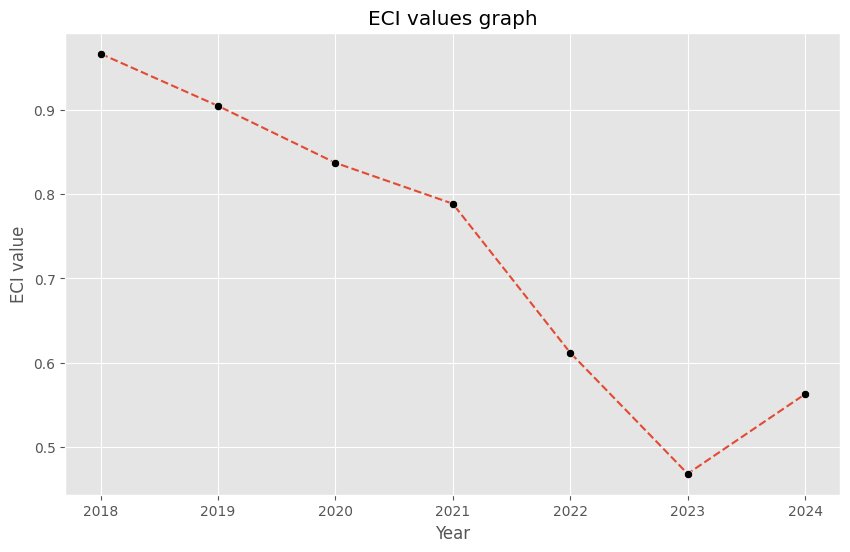

In [26]:
ECI_russia = ECI['Russia']

plt.figure(figsize=(10, 6))
sns.lineplot(x=ECI_russia.index, y=ECI_russia, color='C0', ls='--')
sns.scatterplot(x=ECI_russia.index, y=ECI_russia, color='black', zorder=2)
plt.ylabel('ECI value')
plt.title('ECI values graph')
plt.show()

Индекс экономической сложности ECI показывает интересную тенденцию: с 2018 по 2023 год он падает, а в 2024 году растет. На протяжении всего периода ECI сохранял положительную величину, что свидетельствует о сохранении уровня диверсификации и технологичности, превышая средне-мировые показатели. Динамика ECI может быть связана со следующими причинами:

1. 2018-2019 год - рост и развитие технологических производств в мире, повышение общего уровня сложности мира.
2. 2020-2022 - последствия ковида
3. 2022-2023 - санкции, накладываемые на Россию.

Рост в 2024 году же связан с адаптацией росийского экспорта на рынки дружественных стран.

# Гравитационная модель

In [78]:
df_potash_import['iso3_o'] = df_potash_import['Exporter Country'].map(country_to_iso3)
df_potash_import['iso3_d'] = df_potash_import['Importer Country'].map(country_to_iso3)
df_potash_import['Year'] = df_potash_import['Year'].astype(int)
df_potash_import = df_potash_import.dropna(subset=['iso3_o', 'iso3_d'])

merge_columns = ['Year', 'iso3_o', 'iso3_d', 'gdp_o', 'gdp_d', 'dist', 'contig', 'comlang_off', 'fta_wto', 'Trade Value']

geo_columns = ['iso3_o', 'iso3_d', 'dist', 'contig', 'comlang_off', 'fta_wto']
df_geo_passport = df_cepii[geo_columns].drop_duplicates(subset=['iso3_o', 'iso3_d'])

df_gravity = df_potash_import.merge(
    right=df_geo_passport,
    how='inner', 
    on=['iso3_o', 'iso3_d']
) 

for_merge = ['iso3_o', 'iso3_d', 'Trade Value', 'Year', 'dist', 'contig', 'comlang_off', 'fta_wto']
df_gravity = df_gravity.loc[:, for_merge]

In [80]:
countries_o = [c for c in df_gravity['iso3_o'].unique() if isinstance(c, str)]
countries_d = [c for c in df_gravity['iso3_d'].unique() if isinstance(c, str)]

df_wb_gdp_o = load_wb_indicator_batch(countries=countries_o, indicator="NY.GDP.MKTP.CD")\
    .rename(columns=({'country_code': 'iso3_o', 'year': 'Year', 'value': 'gdp_o'}))\
        .dropna().drop(columns=('country'))
df_wb_gdp_d = load_wb_indicator_batch(countries=countries_d, indicator="NY.GDP.MKTP.CD")\
    .rename(columns=({'country_code': 'iso3_d', 'year': 'Year', 'value': 'gdp_d'}))\
        .dropna().drop(columns=('country'))

df_gravity = df_gravity.merge(
    right=df_wb_gdp_o,
    how='left',
    on=['Year', 'iso3_o']
)

df_gravity = df_gravity.merge(
    right=df_wb_gdp_d,
    how='left',
    on=['Year', 'iso3_d']
)

df_gravity['dist'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['dist'].ffill().bfill()
df_gravity['contig'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['contig'].ffill().bfill()
df_gravity['comlang_off'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['comlang_off'].ffill().bfill()
df_gravity['fta_wto'] = df_gravity.groupby(['iso3_o', 'iso3_d'])['fta_wto'].ffill().bfill()

df_gravity = df_gravity.dropna()

Далее будем оценивать страны с помощью гравитационной модели:

$$\ln(\text{Trade Value}_{ijt}) = \beta_0 + \beta_1 \ln(\text{gdp\_o}_{it}) + \beta_2 \ln(\text{gdp\_d}_{jt}) + \beta_3 \ln(\text{dist}_{ij}) + \\ + \gamma_1 \text{contig}_{ij} + \gamma_2 \text{comlang\_off}_{ij} + \gamma_3 \text{fta\_wto}_{ijt}$$

1. Trade Value - объем торговли
2. gdp_o - ВВП экспортера
3. gdp_d - ВВР импортера
4. dist - расстояние между странами
5. contig - наличие общей границы
6. comlang - наличие общего языка
7. fta_wto - действие соглашения о свободной торговле

In [81]:
features = ['Trade Value', 'gdp_o', 'gdp_d', 'dist', 'contig', 'comlang_off', 'fta_wto', 'iso3_o', 'iso3_d']
years_result = []

for year in df_gravity['Year'].unique():

    mask = df_gravity['Year'] == year
    df_year = df_gravity[mask].loc[:, features]
    
    df_year['ln_gdp_o'] = np.log(df_year['gdp_o'])
    df_year['ln_gdp_d'] = np.log(df_year['gdp_d'])
    df_year['ln_dist'] = np.log(df_year['dist'])
    
    model_cols = ['ln_gdp_o', 'ln_gdp_d', 'ln_dist', 'contig', 'comlang_off', 'fta_wto', 'Trade Value']
    df_year = df_year.replace([np.inf, -np.inf], np.nan).dropna(subset=model_cols)
    
    y = np.log(df_year['Trade Value'] + 1)
    X = df_year.drop(columns=['Trade Value', 'gdp_o', 'gdp_d', 'dist', 'iso3_d', 'iso3_o'])    

    X = sm.add_constant(X)
    grav_model = sm.OLS(y, X)
    results = grav_model.fit(cov_type='HC3')

    df_year['Predict'] = np.exp(results.predict(X)) - 1
    df_year['Delta'] = df_year['Predict'] - df_year['Trade Value']
    df_pred_year = df_year.loc[:, ['iso3_o', 'iso3_d', 'Trade Value', 'Predict', 'Delta']]

    years_result.append([int(year), df_pred_year])

In [82]:
print('Оценка гравитационной модели экспорта калийных удобрений за 2024 год')
print(results.summary())

print()

print('Значения p-value для выбранных переменных')

p_values_df = pd.DataFrame({'p-values': results.pvalues}).round(2)
p_values_df['stat singificace'] = np.where(p_values_df['p-values'] <= 0.01, '*', np.where(p_values_df['p-values'] <= 0.05, '**', np.where(p_values_df['p-values'] <= 0.1, '***', 'not')))

display(p_values_df)
print('***: p-value <= 0.1, **: p-value <= 0.05, *: p-value <= 0.01')

Оценка гравитационной модели экспорта калийных удобрений за 2024 год
                            OLS Regression Results                            
Dep. Variable:            Trade Value   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     12.17
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.91e-13
Time:                        09:10:46   Log-Likelihood:                -2688.4
No. Observations:                1049   AIC:                             5391.
Df Residuals:                    1042   BIC:                             5425.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

,p-values,stat singificace
const,0.02,**
contig,0.00,*
comlang_off,0.29,not
fta_wto,0.57,not
ln_gdp_o,0.00,*
ln_gdp_d,0.22,not
ln_dist,0.01,*


***: p-value <= 0.1, **: p-value <= 0.05, *: p-value <= 0.01


Для экспорта калийных удобрений в 2024 году гравитационная модель подтвердила статистическую значимость на уровне p-value <= 0.05 следующий категорий: константы, общей границы, ВВП экспортера и расстояния между странами. Данные переменные показывают тенденции к переменам на рынке калийных удобрений, сводящиеся к простоте логистики и экономическим возможностям экспортера. При этом наименее значима экономическая ситуация страны-импортера, что может указывать на избыток удобрений, находящихся на мировом рынке после глобальных изменений.

Так же странным наблюдением является то, что модель объясняет всего 7% данных.

Будем измерять потенциал стран как $\Delta = \text{Model Predict} - \text{Real Data}$, чем больше $\Delta$, тем больше у страны есть потенциал к торговле. 

In [83]:
for object in years_result:
    year = object[0]
    df_pred_year = object[1]
    df_pred_year = df_pred_year[df_pred_year['iso3_o'] == 'RUS'].drop(columns='iso3_o')
    df_pred_year['iso3_d'] = df_pred_year['iso3_d'].copy().map(iso3_to_ru)

    df_no_use_potential = df_pred_year.sort_values(by='Delta', ascending=False).head(10)
    df_very_big = df_pred_year.sort_values(by='Delta', ascending=True).head(10)

    print('=' * 80)
    print(f'Топ 10 стран с нереализованным потенциалом экспорта для {year} года')
    print('=' * 80)

    display(df_no_use_potential.round(2))

    print('=' * 80)
    print(f'Топ 10 стран с сверхинтенсивным экспортом для {year} года')
    print('=' * 80)

    display(df_very_big.round(2))

Топ 10 стран с нереализованным потенциалом экспорта для 2018 года


,iso3_d,Trade Value,Predict,Delta
707,Беларусь,4803.0,47657.92,42854.92
703,Кыргызстан,1520.0,22164.03,20644.03
706,Узбекистан,203.0,18172.60,17969.60
708,Украина,34495.0,52419.56,17924.56
704,Южная Корея,18300.0,27092.52,8792.52
713,Эквадор,27767.0,29948.38,2181.38
697,Кот-д'Ивуар,35916.0,22323.03,-13592.97
699,Зимбабве,71432.0,23678.30,-47753.70
709,Доминиканская Республика,239031.0,26541.02,-212489.98
711,Сальвадор,313669.0,26491.73,-287177.27


Топ 10 стран с сверхинтенсивным экспортом для 2018 года


,iso3_d,Trade Value,Predict,Delta
701,Индия,16075853.0,24477.76,-16051375.24
710,Гондурас,11673529.0,26222.37,-11647306.63
705,Малайзия,5434365.0,27040.12,-5407324.88
700,Китай,4295899.0,153343.11,-4142555.89
712,США,1830605.0,33014.59,-1797590.41
702,Казахстан,1506591.0,133515.38,-1373075.62
698,Уганда,630728.0,20803.63,-609924.37
711,Сальвадор,313669.0,26491.73,-287177.27
709,Доминиканская Республика,239031.0,26541.02,-212489.98
699,Зимбабве,71432.0,23678.30,-47753.70


Топ 10 стран с нереализованным потенциалом экспорта для 2019 года


...

,iso3_d,Trade Value,Predict,Delta
6099,США,24823919.0,36262.55,-24787656.45
6095,Малайзия,5170313.0,27419.83,-5142893.17
6096,Гватемала,3919348.0,28337.74,-3891010.26
6092,Китай,3011352.0,256114.23,-2755237.77
6093,Казахстан,2813229.0,166032.14,-2647196.86
6097,Панама,1185472.0,27846.81,-1157625.19
6098,Сальвадор,110040.0,26088.55,-83951.45
6094,Кыргызстан,70497.0,17343.08,-53153.92
6091,ОАЭ,218.0,19417.15,19199.15


Топ 10 стран с нереализованным потенциалом экспорта для 2024 года


,iso3_d,Trade Value,Predict,Delta
7166,Польша,1.0,89720.66,89719.66
7165,Таиланд,334.0,25249.71,24915.71
7167,Словакия,2997.0,14088.81,11091.81
7158,Уганда,13492.0,20388.25,6896.25
7168,Доминиканская Республика,27811.0,24924.61,-2886.39
7161,Кыргызстан,56542.0,16442.35,-40099.65
7162,Камбоджа,165916.0,21555.00,-144361.00
7163,Шри-Ланка,374452.0,21775.34,-352676.66
7157,Мозамбик,1009859.0,21747.25,-988111.75
7159,Китай,2274062.0,202336.03,-2071725.97


Топ 10 стран с сверхинтенсивным экспортом для 2024 года


,iso3_d,Trade Value,Predict,Delta
7164,Малайзия,42032389.0,26011.67,-42006377.33
7160,Казахстан,4873419.0,127612.46,-4745806.54
7169,Гватемала,4136961.0,25976.55,-4110984.45
7170,США,2589999.0,34639.54,-2555359.46
7159,Китай,2274062.0,202336.03,-2071725.97
7157,Мозамбик,1009859.0,21747.25,-988111.75
7163,Шри-Ланка,374452.0,21775.34,-352676.66
7162,Камбоджа,165916.0,21555.00,-144361.00
7161,Кыргызстан,56542.0,16442.35,-40099.65
7168,Доминиканская Республика,27811.0,24924.61,-2886.39


Тут стоит смотреть на последние года, так как в них произошли глобальные изменения в стране. Смотрим за 2022-2024 года: в целом кандидатами на экспорт являются Литва, Сальвадор, ОАЭ, Польша, Таиланд, Словакия, Уганда. Главным претендентом является Таиланд, так как это аграрная страна с немалым количеством плодовых деревьев, для который очень нужны калийные удобрения. Так же Азия не вводила прямых санкций на наши удобрения, что позволит нам без проблем торговать с ними.

# Анализ панельных данных

In [49]:
df_comtarade = df_potash_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'potash value'})\
    .merge(right=df_gas_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'gas value'}), on='period', how='left')\
        .merge(right=df_tomato_comtrade.copy().loc[:, ['period', 'primaryValue']].rename(columns={'primaryValue': 'tomato value'}), on='period', how='left')\
            .rename(columns={'period': 'date'})
df_comtarade['date'] = pd.to_datetime(df_comtarade['date'], format='%Y%m')
df_comtarade = df_comtarade.set_index('date').sort_index(ascending=True)

Построим несколько обзорных графиков

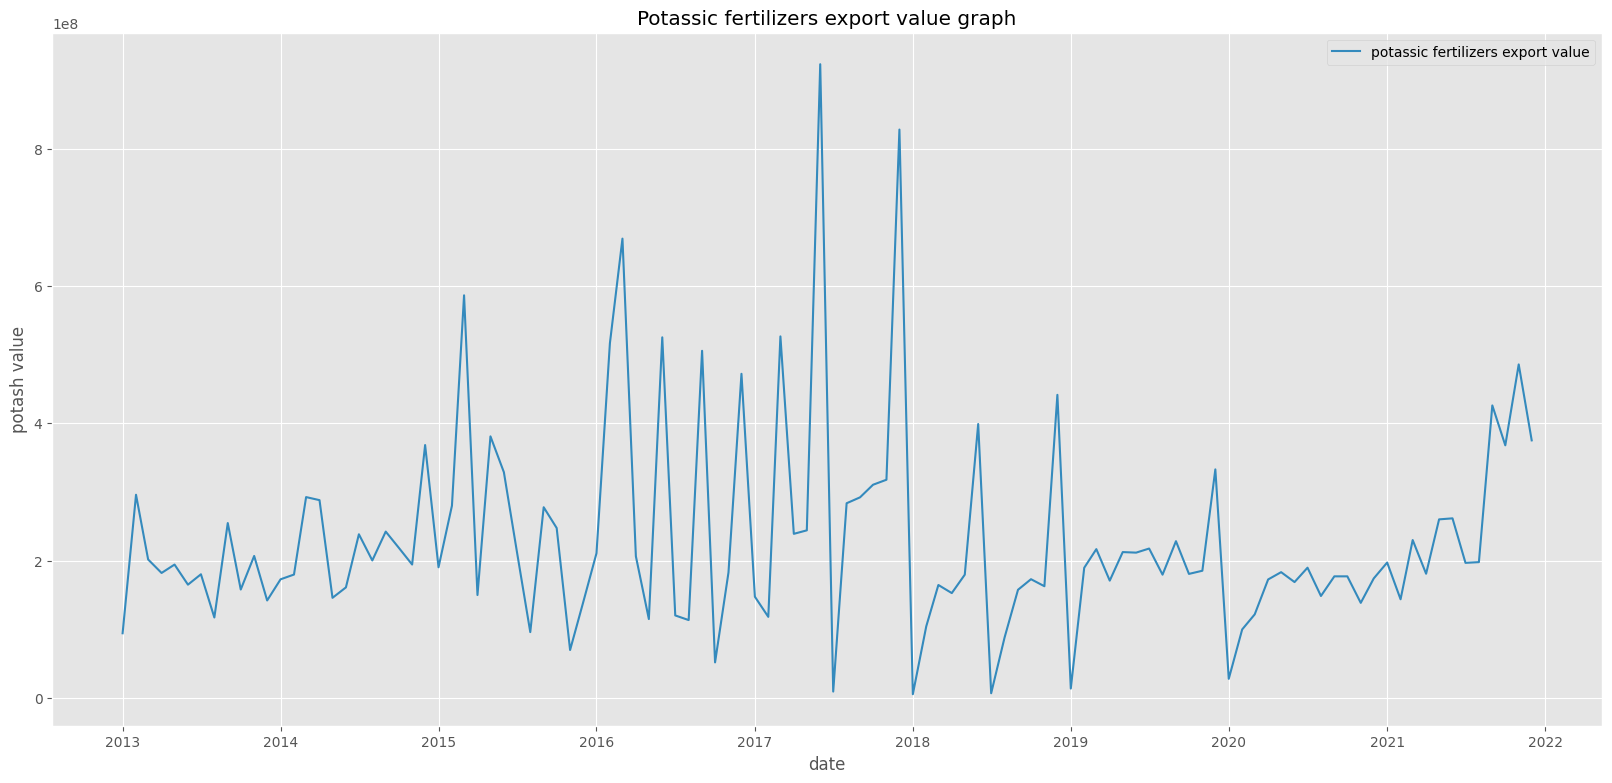

In [51]:
df_potash_time = df_comtarade.loc[:, ['potash value']]

plt.figure(figsize=(20, 9))
sns.lineplot(x=df_potash_time.index, y=df_potash_time['potash value'], color='C1', label='potassic fertilizers export value')
plt.title('Potassic fertilizers export value graph')
plt.show()

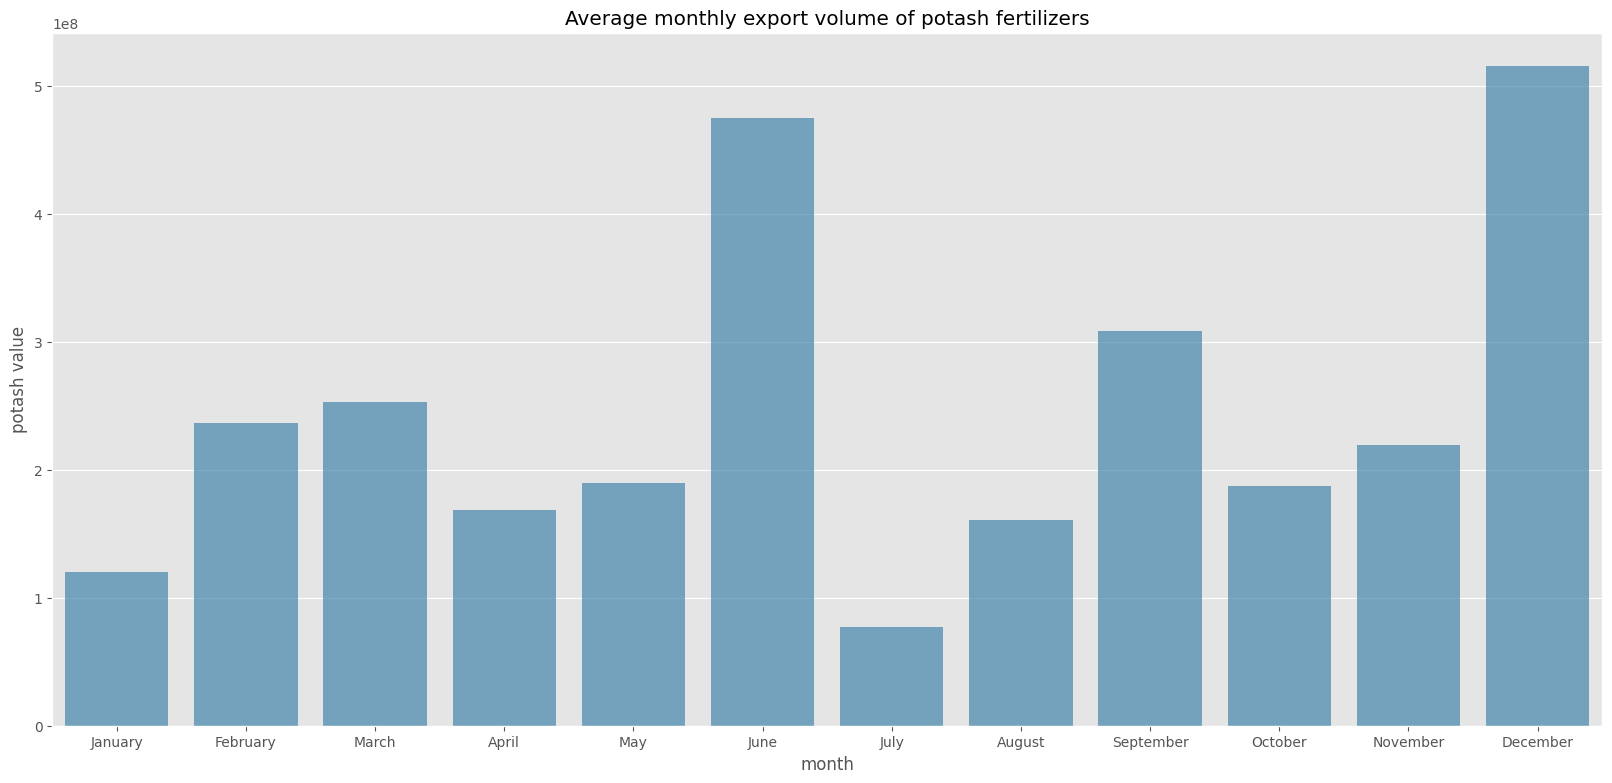

In [52]:
df_potash_time["month_num"] = df_potash_time.index.month
month_mean = df_potash_time.groupby(['month_num']).mean()
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
month_mean['month'] = months
month_mean = month_mean.set_index('month')

plt.figure(figsize=(20, 9))
sns.barplot(x=month_mean.index, y=month_mean['potash value'], color='C1', alpha=0.7)
plt.title('Average monthly export volume of potash fertilizers')
plt.show()

Как видим, в среднем в июне и декабре самые большие значения экспорта удобрений, что может говорить о сезонности. Проверим это с помощью STL-декомпозиции:

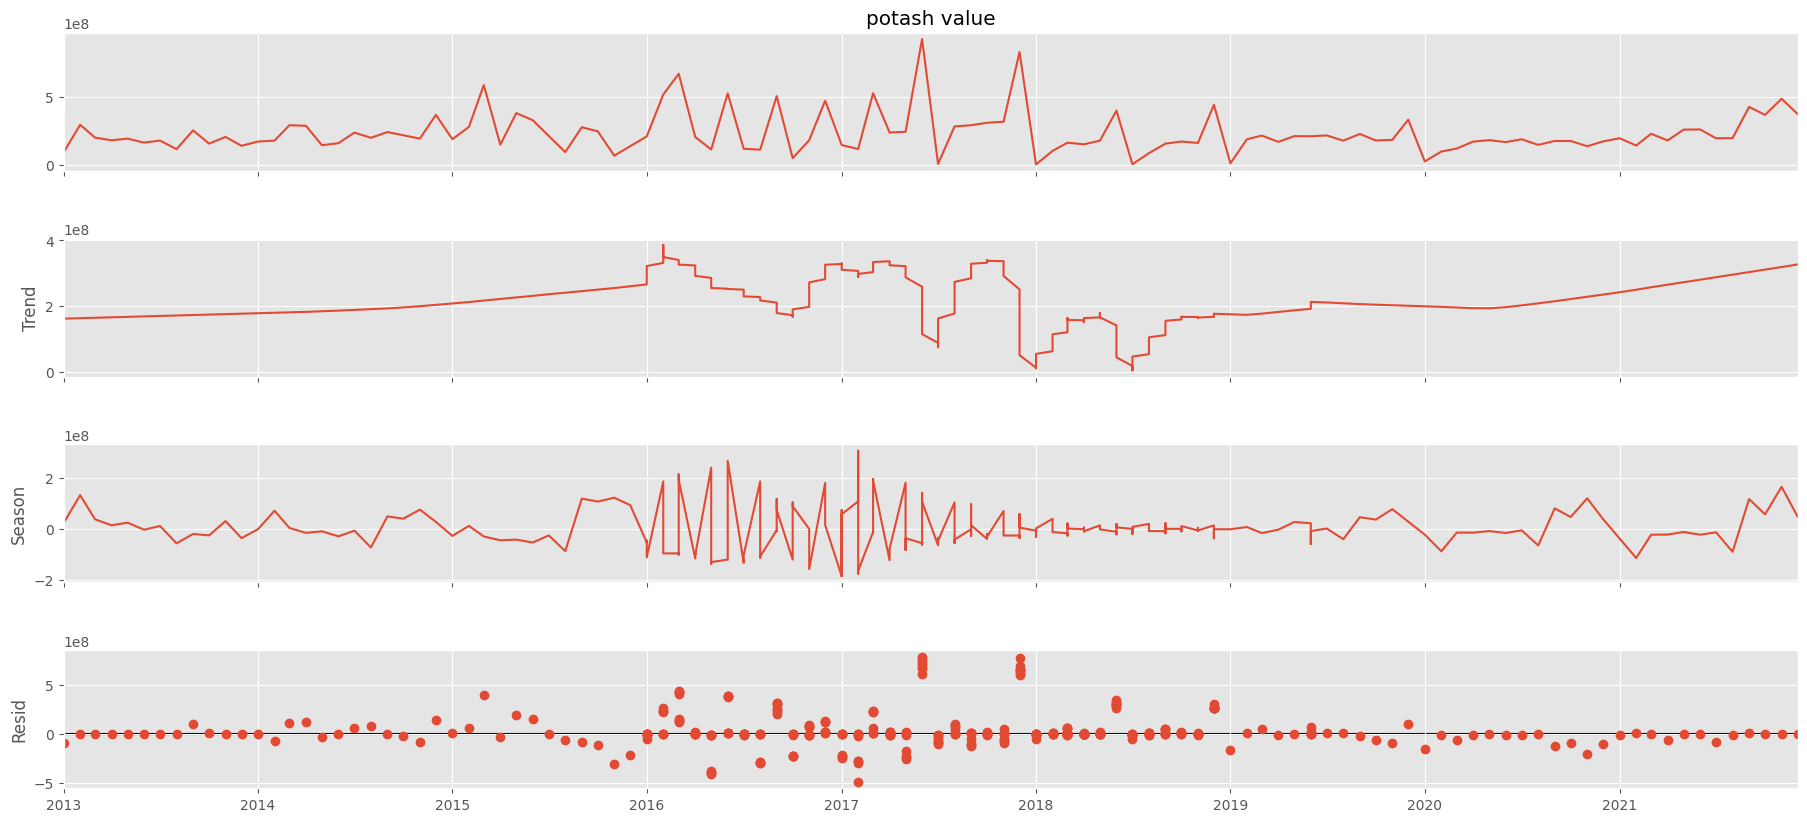

In [53]:
stl = STL(df_potash_time['potash value'], period=12, robust=True, seasonal=7)
results = stl.fit()

fig = results.plot()
fig.set_size_inches(20, 9)
fig.show()

Сезонности особо не наблюдается, но так же наблюдается бум значений в 2017 году, где на максимумы пришлись как раз июнь и декабрь, что сильно завышает их среднее. 

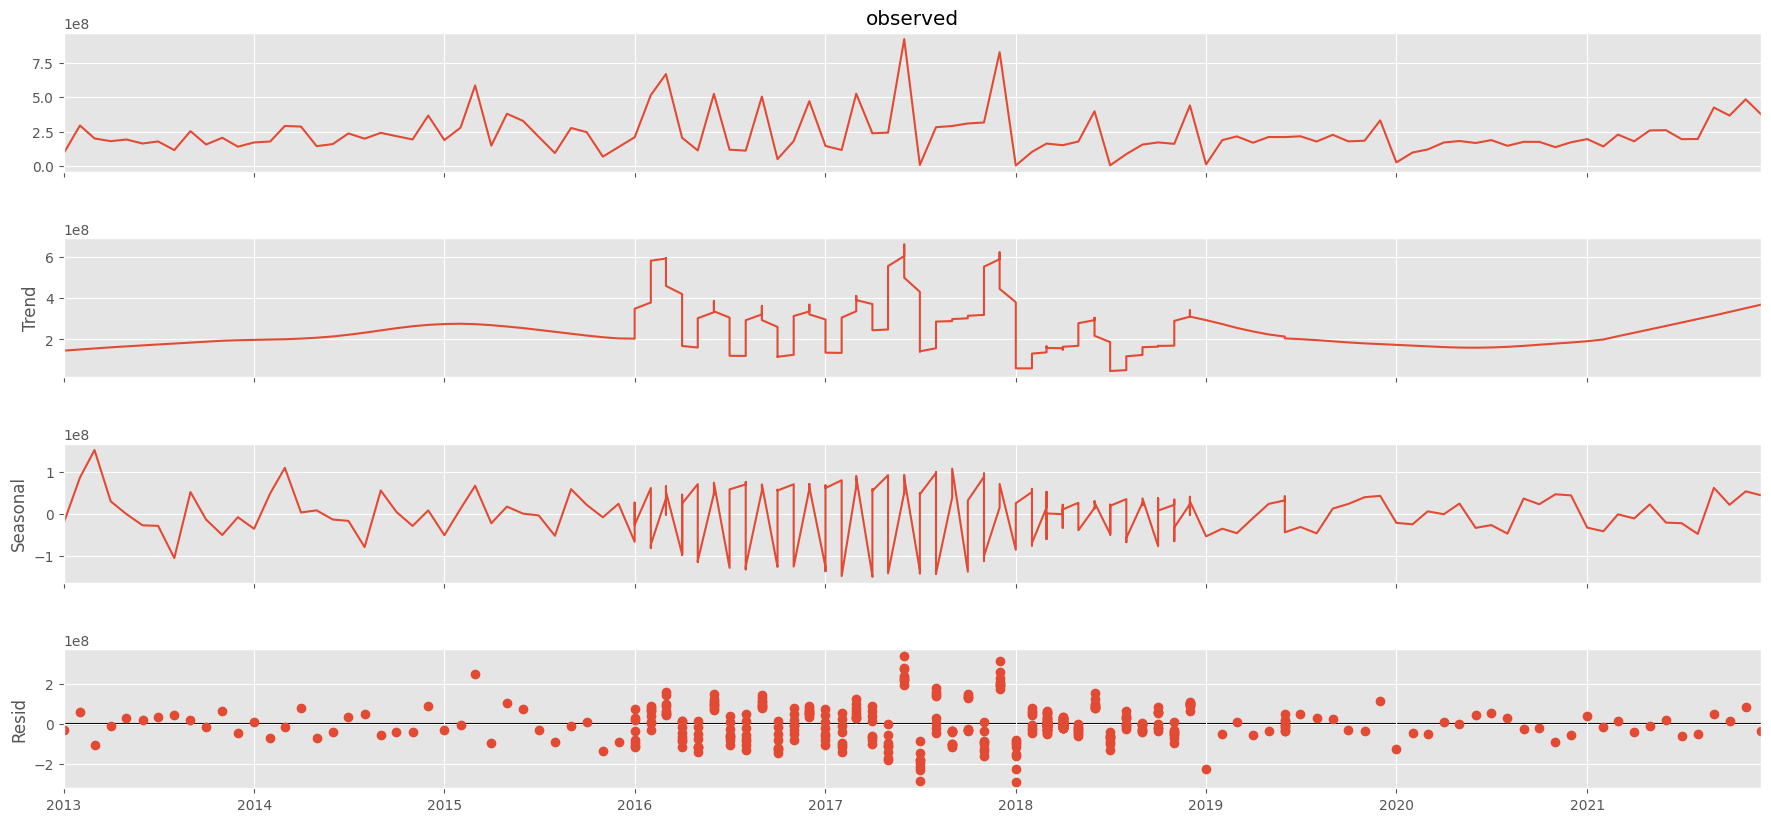

In [54]:
mstl = MSTL(df_potash_time['potash value'], periods=12)
res = mstl.fit()

fig = res.plot()
fig.set_size_inches(20, 9)
plt.show()

Вот тут уже проявляется сезонность, она как-будто более периодична, чем у STL, значит сезонность все же есть, но ее период составляет 3-5 месяцев.

In [55]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

def MAE(real: pd.Series, pred: pd.Series):
  return mean_absolute_error(real, pred)

def MAPE(real: pd.Series, pred: pd.Series):
  return mean_absolute_percentage_error(real, pred)

def sMAPE(real: pd.Series, pred: pd.Series): # Я брал формулу отсюда: https://en.wikipedia.org/wiki/Symmetric_mean_absolute_percentage_error

  if len(real) != len(pred):
    raise ValueError('Число реальных данных и предиктов должно совпадать!')

  real = np.array(real)
  pred = np.array(pred)

  diff = abs(real - pred)
  znam = abs(real) + abs(pred)

  drob = diff / znam

  return 2 / len(drob) * drob.sum()

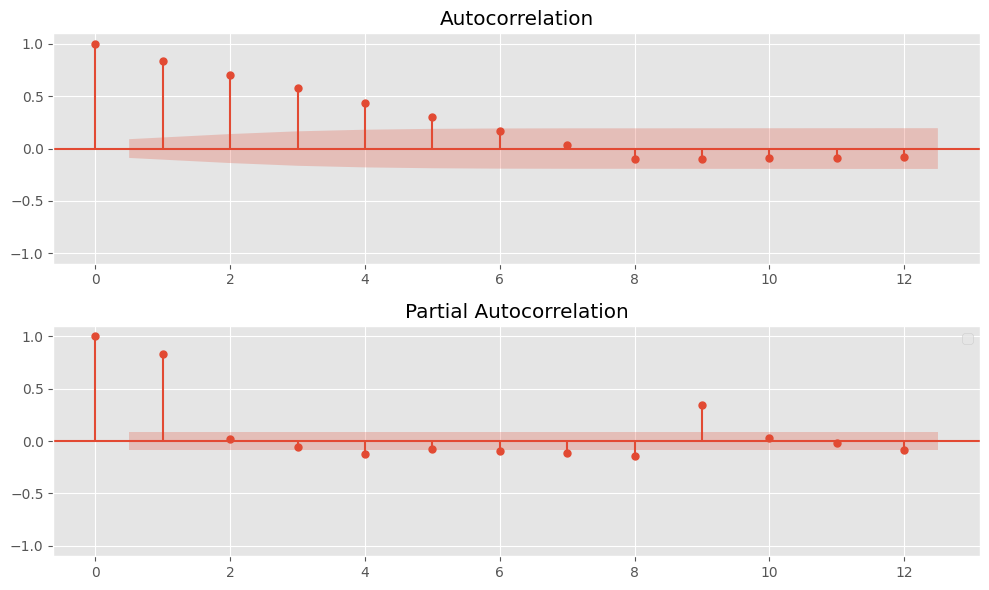

In [56]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

plot_acf(x=df_potash_time['potash value'], lags=12, ax=ax[0])
ax[0].set_title('Autocorrelation')
ax[0].set_ylim(-1.1, 1.1)

plot_pacf(x=df_potash_time['potash value'], lags=12, ax=ax[1])
ax[1].set_title('Partial Autocorrelation')
ax[1].set_ylim(-1.1, 1.1)


plt.legend()
plt.tight_layout()
plt.show()

Наблюдается не сильная кореляция между текущими значениями и прошлыми, кореляции в основном достаточном маленькие, скорее просто случайные. Каких-то повторяющихся "пиков" нету, значит и сезонность отсутствует.

В итоге ACF и PACF показали отсутствие сезонности, вероятно MSTL включил некоторые шумы и нестабильность в сезонность, что и привело к соответствующему графику.

Далее проведем ADF и KPSS тесты

In [57]:
# Взято отсюда: https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

In [58]:
adf_test(df_potash_time['potash value'])
print()
kpss_test(df_potash_time['potash value'])

Results of Dickey-Fuller Test:
Test Statistic                  -3.148750
p-value                          0.023150
#Lags Used                      17.000000
Number of Observations Used    461.000000
Critical Value (1%)             -3.444615
Critical Value (5%)             -2.867830
Critical Value (10%)            -2.570120
dtype: float64

Results of KPSS Test:
Test Statistic            0.624189
p-value                   0.020437
Lags Used                11.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64


Мы видим, что ADF p-value < 0.05 и KPSS p-value < 0.05, значит ряд не стационарен, дальше будем работать с первыми разностями:

Рассмотрим модели ARIMA, SARIMA, SARIMAX

In [59]:
df_potash_time = df_potash_time.diff(1)

arima_model = SARIMAX(endog=df_potash_time['potash value'], order=(1, 1, 1), trend='c')

sarima_model = SARIMAX(endog=df_potash_time['potash value'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')


exog = df_comtarade.drop(columns=['potash value'])
sarimax_model = SARIMAX(endog=df_potash_time['potash value'], exog=exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')

In [38]:
arima_res = arima_model.fit()
print(arima_res.summary())

                               SARIMAX Results                                
Dep. Variable:           potash value   No. Observations:                  479
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -9511.616
Date:                Wed, 27 May 2026   AIC                          19031.232
Time:                        08:51:29   BIC                          19047.910
Sample:                             0   HQIC                         19037.789
                                - 479                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.622e+04    6.7e+04      0.690      0.490   -8.51e+04    1.78e+05
ar.L1         -0.1000      0.062     -1.606      0.108      -0.222       0.022
ma.L1         -0.9958      0.018    -55.877      0.0

In [39]:
sarima_res = sarima_model.fit()
print(sarima_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       potash value   No. Observations:                  479
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -9309.503
Date:                            Wed, 27 May 2026   AIC                          18631.005
Time:                                    08:51:33   BIC                          18655.870
Sample:                                         0   HQIC                         18640.791
                                            - 479                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2.074e+05   2.82e+05      0.736      0.462   -3.45e+05    7.59e+05
ar.L1         -0.1090      0.115   

In [40]:
sarimax_res = sarimax_model.fit()
print(sarimax_res.summary())

                                     SARIMAX Results                                      
Dep. Variable:                       potash value   No. Observations:                  479
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -9313.533
Date:                            Wed, 27 May 2026   AIC                          18643.066
Time:                                    08:51:35   BIC                          18676.220
Sample:                                         0   HQIC                         18656.114
                                            - 479                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept     2.424e+05   3.07e+05      0.790      0.429   -3.59e+05    8.44e+05
gas value       -0.0207      

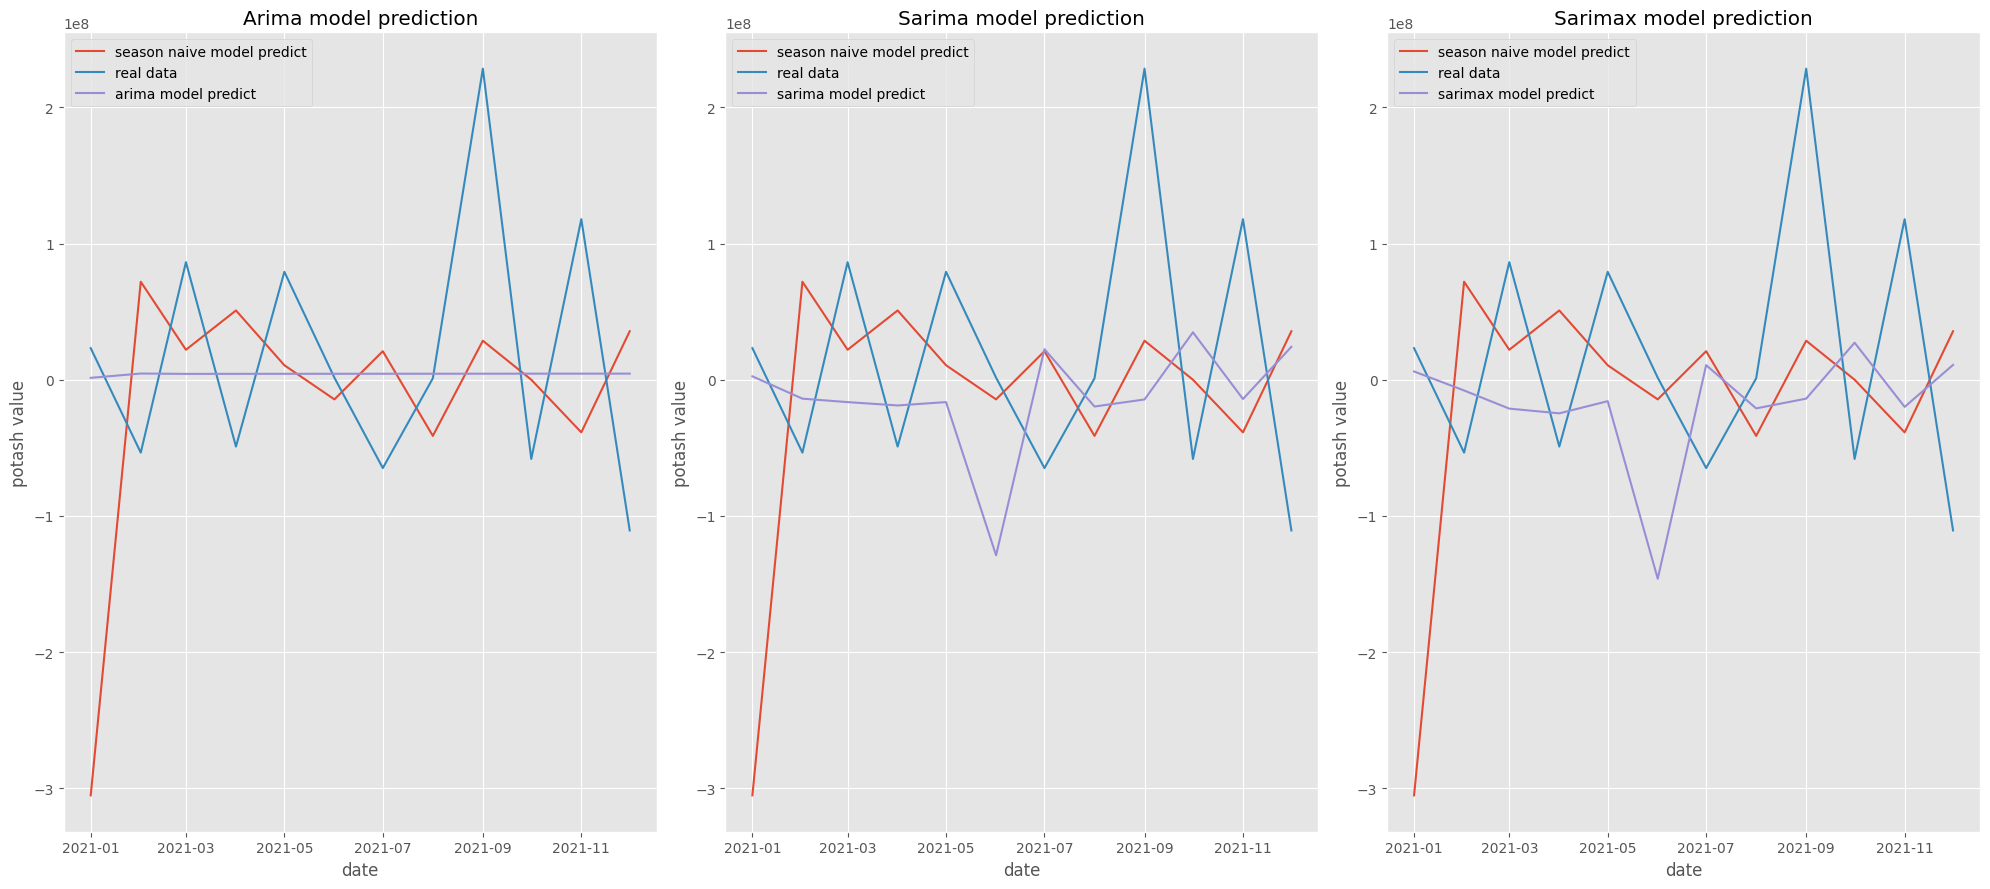

In [41]:
df_train, df_test = df_potash_time.iloc[:-12], df_potash_time.iloc[-12:]
exog_train, exog_test = exog.iloc[:-12], exog.iloc[-12:]

arima_model = SARIMAX(endog=df_train['potash value'], order=(1, 1, 1), trend='c')
sarima_model = SARIMAX(endog=df_train['potash value'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')
sarimax_model = SARIMAX(endog=df_train['potash value'], exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), trend='c')

arima_predict = arima_model.fit().get_forecast(steps=len(df_test)).predicted_mean
sarima_predict = sarima_model.fit().get_forecast(steps=len(df_test)).predicted_mean
sarimax_predict = sarimax_model.fit().get_forecast(steps=len(df_test), exog=exog_test).predicted_mean

naive_model_predict = df_train.iloc[-12:]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 9))

sns.lineplot(ax=ax[0], x=df_test.index, y=naive_model_predict['potash value'], color='C0', label='season naive model predict')
sns.lineplot(ax=ax[0], x=df_test.index, y=df_test['potash value'], color='C1', label='real data')
sns.lineplot(ax=ax[0], x=df_test.index, y=arima_predict, color='C2', label='arima model predict')
ax[0].set_title('Arima model prediction')

sns.lineplot(ax=ax[1], x=df_test.index, y=naive_model_predict['potash value'], color='C0', label='season naive model predict')
sns.lineplot(ax=ax[1], x=df_test.index, y=df_test['potash value'], color='C1', label='real data')
sns.lineplot(ax=ax[1], x=df_test.index, y=sarima_predict, color='C2', label='sarima model predict')
ax[1].set_title('Sarima model prediction')

sns.lineplot(ax=ax[2], x=df_test.index, y=naive_model_predict['potash value'], color='C0', label='season naive model predict')
sns.lineplot(ax=ax[2], x=df_test.index, y=df_test['potash value'], color='C1', label='real data')
sns.lineplot(ax=ax[2], x=df_test.index, y=sarimax_predict, color='C2', label='sarimax model predict')
ax[2].set_title('Sarimax model prediction')

plt.tight_layout()
plt.show()

Тут мы видим, что модели SARIMA и SARIMAX почти не отличаются в предсказаниях, а модель ARIMA дает просто прямую.

In [42]:
data = {
    'MAE': [
        MAE(df_test['potash value'], naive_model_predict['potash value']),
        MAE(df_test['potash value'], arima_predict),
        MAE(df_test['potash value'], sarima_predict),
        MAE(df_test['potash value'], sarimax_predict)
    ],
    'MAPE': [
        MAPE(df_test['potash value'], naive_model_predict['potash value']),
        MAPE(df_test['potash value'], arima_predict),
        MAPE(df_test['potash value'], sarima_predict),
        MAPE(df_test['potash value'], sarimax_predict)
    ],
    'sMAPE': [
        sMAPE(df_test['potash value'], naive_model_predict['potash value']),
        sMAPE(df_test['potash value'], arima_predict),
        sMAPE(df_test['potash value'], sarima_predict),
        sMAPE(df_test['potash value'], sarimax_predict)
    ]
}

df_metrics = pd.DataFrame(index = ['naive', 'arima', 'sarima', 'sarimax'], data=data)
display(df_metrics)

,MAE,MAPE,sMAPE
naive,1.159966e+08,6.428225,1.855767
arima,7.342838e+07,1.272197,1.780660
sarima,9.420250e+07,9.842552,1.806263
sarimax,9.352779e+07,10.868490,1.776457


Тут модель ARIMA показала себя лучше всего, выбив наименьшие скоры. Связанно это с тем, что SARIMA и SARIMAX дают смещение в другую сторону от роста функции, из-за чего метрики увеличиваются, а не уменьшаются.

Теперь перейдем к изучению шоков связанных с экзогенными переменными. Экзогенными переменными стали газ (основное топливо для заводов и в том числе по производству удобрений, важный товар который может отказать не маленькое влияние на остальные товары) и помидоры (культура, нуждающаяся в калийных удобрениях для роста, а так же скоропортящийся товар, что так же будет оказывать влияние на экспорт удобрений).

In [ ]:
for col in df_comtarade.columns:
    p_value_adf = adfuller(df_comtarade[col], autolag='AIC', regression='c')[1]
    p_value_kpss = kpss(df_comtarade[col], regression='c')[1]

    if p_value_adf < 0.05 and p_value_kpss > 0.05:
        print(f'Ряд {col} - стационарен')
    else:
        print(f'Ряд {col} - не стационарен')

Ряд potash value - не стационарен
Ряд gas value - не стационарен
Ряд tomato value - не стационарен


Рассмотрим первые разности

In [ ]:
df_comtarade_delta_1 = df_comtarade.copy().diff(1).dropna()
for col in df_comtarade_delta_1.columns:
    p_value_adf = adfuller(df_comtarade_delta_1[col], autolag='AIC', regression='c')[1]
    p_value_kpss = kpss(df_comtarade_delta_1[col], regression='c')[1]

    if p_value_adf < 0.05 and p_value_kpss > 0.05:
        print(f'Ряд {col} - стационарен')
    else:
        print(f'Ряд {col} - не стационарен')

Ряд potash value - стационарен
Ряд gas value - стационарен
Ряд tomato value - стационарен


Отлично, тут все стацонарно, значит продолжим работать с первыми разностями и проведем Granger Causality Test.

In [ ]:
n = len(df_comtarade_delta_1.columns)

matrix = np.zeros((n, n))
df_results = pd.DataFrame(matrix, columns=df_comtarade_delta_1.columns, index=df_comtarade_delta_1.columns)

for y in df_comtarade_delta_1.columns:
    for x in df_comtarade_delta_1.columns:
        if x == y:
            continue
        grangercausalitytests_result = grangercausalitytests(x=df_comtarade_delta_1[[y, x]], maxlag=4)
        p_value = grangercausalitytests_result[4][0]['ssr_chi2test'][1] 
        df_results.loc[x, y] = p_value


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0054  , p=0.9416  , df_denom=474, df_num=1
ssr based chi2 test:   chi2=0.0054  , p=0.9414  , df=1
likelihood ratio test: chi2=0.0054  , p=0.9414  , df=1
parameter F test:         F=0.0054  , p=0.9416  , df_denom=474, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1436  , p=0.8663  , df_denom=471, df_num=2
ssr based chi2 test:   chi2=0.2903  , p=0.8649  , df=2
likelihood ratio test: chi2=0.2902  , p=0.8649  , df=2
parameter F test:         F=0.1436  , p=0.8663  , df_denom=471, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3742  , p=0.7717  , df_denom=468, df_num=3
ssr based chi2 test:   chi2=1.1393  , p=0.7676  , df=3
likelihood ratio test: chi2=1.1379  , p=0.7679  , df=3
parameter F test:         F=0.3742  , p=0.7717  , df_denom=468, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.3194  , p=0.8650  

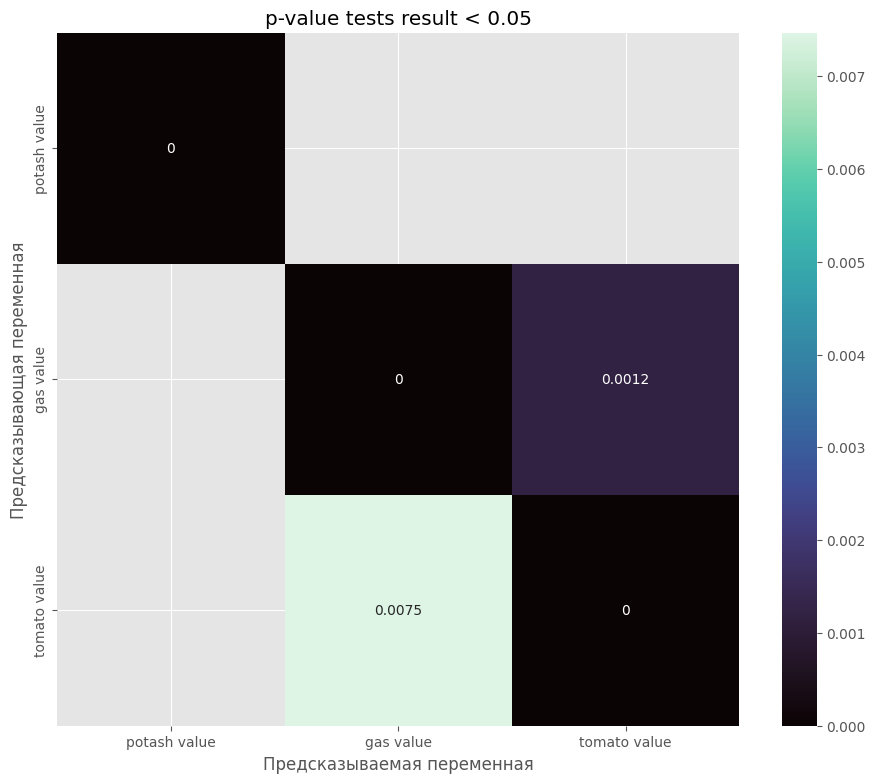

In [ ]:
plt.figure(figsize=(11, 9))

mask = df_results < 0.05

sns.heatmap(data=df_results[mask], annot=True, cmap='mako', fmt='.2g')
plt.title('p-value tests result < 0.05')
plt.xlabel('Предсказываемая переменная')
plt.ylabel('Предсказывающая переменная')
plt.show()

Тест показал только 2 статзначимых зависимости - gas от tomato и tomato от gas. Это интересно, потому что томаты и газ сами по себе не очень очевидно связаны. Тут вероятна связь между отоплением и освещеним теплиц от газа, из-за чего трудности в его поставке бьют по урожаю помидоров.  

Далее проведем тест Йохансена для стандартных рядов

In [ ]:
johansen = coint_johansen(df_comtarade, k_ar_diff=3, det_order=0)

print(f'Trace statistic: \n{johansen.lr1}\n')
print(f'Critical value trace: \n{johansen.cvt}\n')

rank = 0
for i in range(len(johansen.lr1)):
    if johansen.lr1[i] > johansen.cvt[i, 1]:
        rank = rank + 1
    else:
        break
print(f'Ранг: {rank}')

johansen_table = pd.DataFrame(index=["r=0", "r<=1", "r<=2"])
johansen_table["trace_stat"] = johansen.lr1
johansen_table["cv95"] = johansen.cvt[:, 1]
johansen_table["reject?"] = johansen_table["trace_stat"] > johansen_table["cv95"]
johansen_table.round(2)

Trace statistic: 
[82.46189701 36.18408878 16.26955362]

Critical value trace: 
[[27.0669 29.7961 35.4628]
 [13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]

Ранг: 3


,trace_stat,cv95,reject?
r=0,82.46,29.80,True
r<=1,36.18,15.49,True
r<=2,16.27,3.84,True


Так как ранг модели 3 из 3, то выбираем обычную VAR модель для стандартных рядов, а не первых разностей.

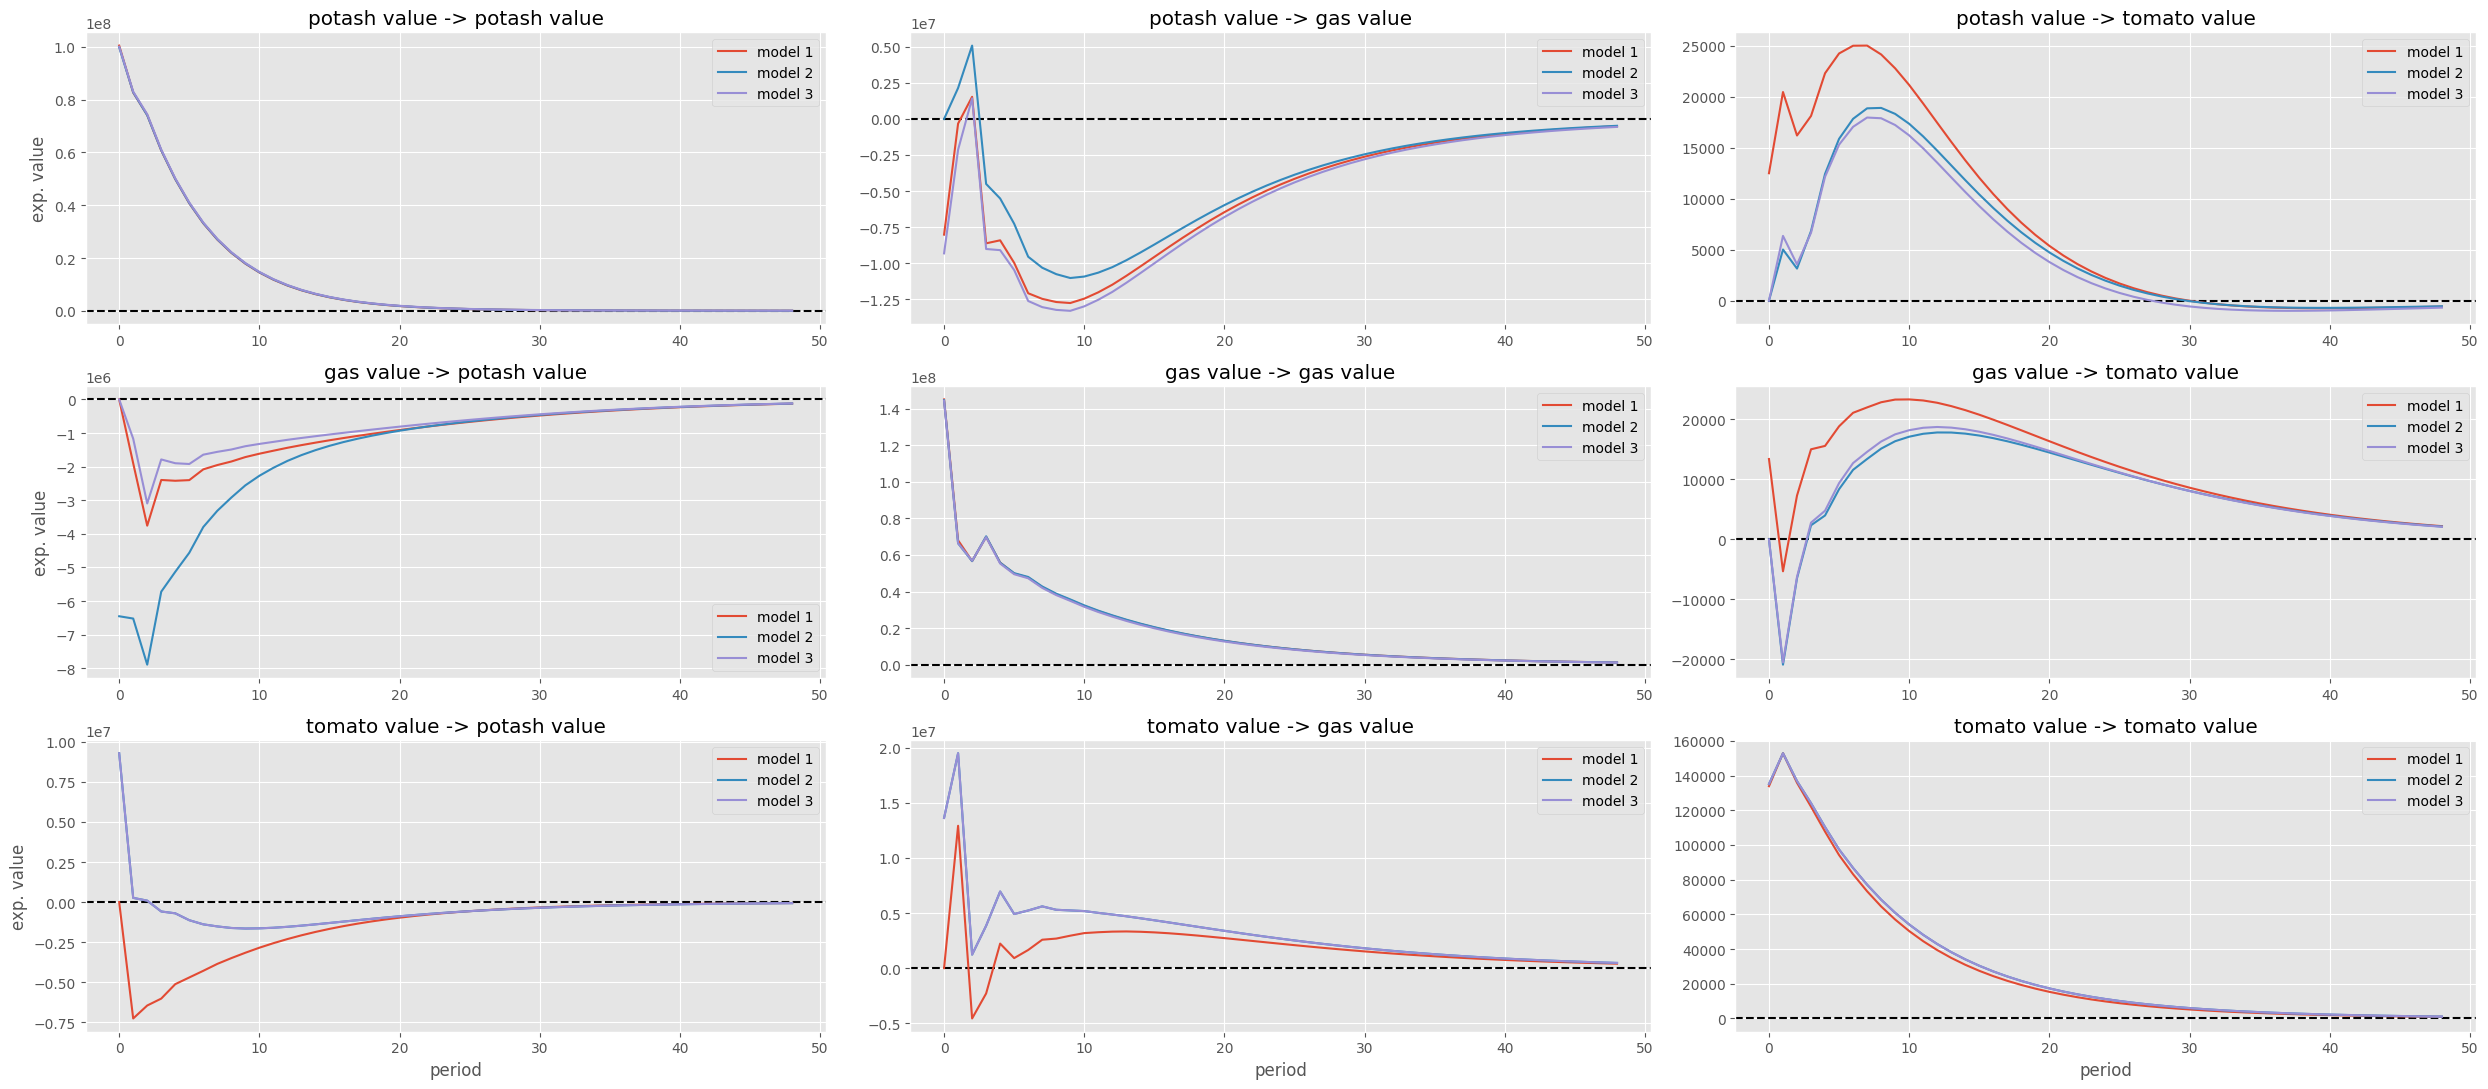

In [ ]:
df_comtarade1 = df_comtarade.loc[:, ['potash value', 'gas value', 'tomato value']] 
df_comtarade2 = df_comtarade.loc[:, ['tomato value', 'gas value', 'potash value']] 
df_comtarade3 = df_comtarade.loc[:, ['tomato value', 'potash value', 'gas value']]

period = 48

model_var1 = VAR(endog=df_comtarade1)
res1 = model_var1.fit(3, ic='aic')
var_irf1 = res1.irf(periods=period) 

model_var2 = VAR(endog=df_comtarade2)
res2 = model_var2.fit(3, ic='aic')
var_irf2 = res2.irf(periods=period) 

model_var3 = VAR(endog=df_comtarade3)
res3 = model_var3.fit(3, ic='aic')
var_irf3 = res3.irf(periods=period) 


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 11))

for i, col1 in enumerate(df_comtarade1.columns):
    for j, col2 in enumerate(df_comtarade1.columns):

        ax = axes[i, j]

        ax.axhline(y=0, color='black', ls='--')

        idx_imp1 = df_comtarade1.columns.get_loc(col1)
        idx_res1 = df_comtarade1.columns.get_loc(col2)
        
        idx_imp2 = df_comtarade2.columns.get_loc(col1)
        idx_res2 = df_comtarade2.columns.get_loc(col2)

        idx_imp3= df_comtarade3.columns.get_loc(col1)
        idx_res3 = df_comtarade3.columns.get_loc(col2)

        line1 = var_irf1.orth_irfs[:, idx_res1, idx_imp1]

        line2 = var_irf2.orth_irfs[:, idx_res2, idx_imp2]

        line3 = var_irf3.orth_irfs[:, idx_res3, idx_imp3]
        
        sns.lineplot(data=line1, color='C0', label=f'model 1', ax=ax)
        sns.lineplot(data=line2, color='C1', label=f'model 2', ax=ax)
        sns.lineplot(data=line3, color='C2', label=f'model 3', ax=ax)
        
        ax.set_title(f'{col1} -> {col2}')
        ax.legend()
        if i == 2:
            ax.set_xlabel('period')
        if j == 0:
            ax.set_ylabel('exp. value')


plt.tight_layout() 
plt.show()

Построение IRF для разного порядка переменных на период 48 месяцев показывает их сходимость обратно к нулю, то есть за 4 года экспорт страны оправится от любого шока и прийдет в изначальное состояние без изменений. Это говорит нам об устойчивости экспорта калийных удобрений.